# Embedding Model Comparison for RAG Quality

Compare how different embedding models affect retrieval and answer quality,
without modifying the main pipeline artifacts (`embeddings.npy`, `uchicago_ads_faiss.index`).

**Models tested:**
- `all-MiniLM-L6-v2` (384-dim) — current production model, English-only
- `BAAI/bge-m3` (1024-dim, 568M) — open-source, cross-lingual SOTA on MIRACL/MKQA
- `multilingual-e5-large-instruct` (1024-dim, 560M) — strong multilingual open-source
- `gemini-embedding-001` (3072-dim) — Google API, MTEB English #1, 100+ languages

**Metrics:**
- Pseudo-query Recall@1 / Recall@5
- Retrieval score distribution (RRF)
- Side-by-side answer comparison (including Chinese cross-lingual queries)
- RAGAS faithfulness & answer relevancy (optional, slow)

In [12]:
import json
import os
import re
import random
import time
import math
import warnings

import faiss
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
from langchain_google_genai import ChatGoogleGenerativeAI
from google import genai

# RAGAS evaluation
from datasets import Dataset
with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    from ragas import evaluate
    from ragas.metrics import answer_relevancy, faithfulness
    from ragas.llms import LangchainLLMWrapper
    from ragas.embeddings import LangchainEmbeddingsWrapper
    from langchain_community.embeddings import HuggingFaceEmbeddings

load_dotenv()

# Configure Google GenAI client for embedding API
genai_client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))


class GoogleEmbedderWrapper:
    """Wrapper around Google's gemini-embedding-001 to match SentenceTransformer.encode() interface."""

    def __init__(self, model_name="gemini-embedding-001", batch_size=100):
        self.model_name = model_name
        self.batch_size = batch_size

    def encode(self, texts, normalize_embeddings=True, batch_size=None, show_progress_bar=False):
        """Encode texts using Google Embedding API, returns numpy array."""
        if isinstance(texts, str):
            texts = [texts]

        bs = batch_size or self.batch_size
        all_embeddings = []

        for i in range(0, len(texts), bs):
            batch = texts[i : i + bs]
            result = genai_client.models.embed_content(
                model=self.model_name,
                contents=batch,
            )
            all_embeddings.extend([e.values for e in result.embeddings])
            if show_progress_bar:
                print(f"  Google API: {min(i + bs, len(texts))}/{len(texts)} texts embedded")

        vecs = np.array(all_embeddings, dtype="float32")

        if normalize_embeddings:
            norms = np.linalg.norm(vecs, axis=1, keepdims=True)
            norms[norms == 0] = 1
            vecs /= norms

        return vecs


# Load chunks (shared across all models)
with open("chunked_documents.json", "r", encoding="utf-8") as f:
    chunk_records = json.load(f)
print(f"Loaded {len(chunk_records)} chunks")

# BM25 index (shared — does not depend on embedding model)
tokenized = [c["text"].lower().split() for c in chunk_records]
bm25 = BM25Okapi(tokenized)

# Cross-encoder reranker (shared)
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# LLM for answer generation
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    temperature=0.0,
    max_output_tokens=512,
    google_api_key=os.getenv("GOOGLE_API_KEY"),
)

print("Shared resources ready.")

/opt/anaconda3/envs/torch/lib/python3.12/site-packages/instructor/providers/gemini/client.py:5: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai  # type: ignore[import-not-found]


Loaded 1342 chunks
Shared resources ready.


## Retrieval & Reranking Functions

Parameterized versions that accept `embedder` and `faiss_index` as arguments
instead of using globals, so we can swap models easily.

In [2]:
# ---------------------------------------------------------------------------
# List-query detection
# ---------------------------------------------------------------------------
_LIST_RE = re.compile(
    r"\b(\d+)\s*(examples?|instances?|cases?|capstones?|projects?|topics?|courses?|ways?|tips?|ideas?)"
    r"|\b(list|give me|show me|what are|name)\b",
    re.IGNORECASE,
)

def _requested_count(query):
    m = re.search(r"\b(\d+)\s*(examples?|instances?|cases?|capstones?|projects?)", query, re.IGNORECASE)
    return int(m.group(1)) if m else 0

def is_list_query(query):
    return bool(_LIST_RE.search(query))

# ---------------------------------------------------------------------------
# Synonym expansion
# ---------------------------------------------------------------------------
_SYNONYMS = {
    "tuition":              ["cost", "fee", "price", "expense", "how much"],
    "professor":            ["faculty", "instructor", "teacher"],
    "class":                ["course", "subject"],
    "job":                  ["career", "employment", "work", "hire", "company", "role"],
    "career outcomes":      ["hire", "company", "employer", "job placement", "work at"],
    "salary":               ["income", "pay", "compensation", "earning"],
    "apply":                ["application", "admission", "enroll"],
    "admission":            ["application", "how to apply", "eligibility", "requirement"],
    "scholarship":          ["financial aid", "funding", "grant", "award"],
    "online":               ["remote", "virtual", "distance"],
    "deadline":             ["due date", "cutoff"],
    "gpa":                  ["grade", "academic requirement"],
    "visa":                 ["immigration", "sponsorship", "opt", "stem"],
    "capstone":             ["project", "thesis", "final project"],
    "curriculum":           ["core courses", "required courses", "elective courses", "course list"],
    "alumni":               ["graduate", "graduate outcome", "placement"],
    "core courses":         ["required courses", "mandatory classes"],
    "foundational courses": ["before join", "resources before joining", "preparation materials", "pre-course resources"],
}

_REVERSE_SYNONYMS = {}
for key, vals in _SYNONYMS.items():
    for v in vals:
        _REVERSE_SYNONYMS[v] = key

def _phrase_matches(phrase, q_lower):
    q_tokens = set(re.sub(r"[^a-z0-9\s]", " ", q_lower).split())
    words = phrase.split()
    if len(words) == 1:
        return words[0] in q_tokens
    return all(w in q_tokens for w in words)

def expand_query(query):
    q_lower = query.lower()
    extra = []
    all_phrases = sorted(
        list(_SYNONYMS.keys()) + list(_REVERSE_SYNONYMS.keys()),
        key=len, reverse=True
    )
    for phrase in all_phrases:
        if _phrase_matches(phrase, q_lower):
            if phrase in _SYNONYMS:
                extra.extend(_SYNONYMS[phrase])
            else:
                extra.append(_REVERSE_SYNONYMS[phrase])
    return query + " " + " ".join(extra) if extra else query

def is_dup(a, b, thresh=0.95):
    sa, sb = set(a.split()), set(b.split())
    return len(sa & sb) / max(1, len(sa | sb)) > thresh

# ---------------------------------------------------------------------------
# Parameterized retrieval
# ---------------------------------------------------------------------------
def retrieve(query, embedder, faiss_index, top_k=10, dup_thresh=0.95):
    """Hybrid retrieval with BM25 + semantic (FAISS) fused via RRF."""
    listing = is_list_query(query)
    url_cap = 1 if listing else 3

    all_idxs = list(range(len(chunk_records)))
    q_emb = embedder.encode([query], normalize_embeddings=True)[0].astype("float32")
    bm25_scores = bm25.get_scores(expand_query(query).lower().split())

    sub_vecs = np.stack([faiss_index.reconstruct(i) for i in all_idxs])
    sem_scores = sub_vecs @ q_emb

    k = 60
    sem_ranks = np.argsort(-sem_scores)
    bm25_ranks = np.argsort(-bm25_scores)
    rrf = np.zeros(len(all_idxs))
    for rank, rel in enumerate(sem_ranks):
        rrf[rel] += 1.0 / (k + rank + 1)
    for rank, rel in enumerate(bm25_ranks):
        rrf[rel] += 1.0 / (k + rank + 1)

    # Heading boost
    q_tokens = set(re.sub(r"[^a-z0-9\s]", " ", query.lower()).split())
    q_tokens.update(expand_query(query).lower().split())
    for idx in all_idxs:
        heading = (chunk_records[idx]["metadata"].get("heading") or "").lower()
        if not heading:
            continue
        h_tokens = set(heading.split())
        overlap = len(q_tokens & h_tokens) / max(1, len(h_tokens))
        if overlap >= 0.5:
            ctype = chunk_records[idx]["metadata"].get("chunk_type", "")
            multiplier = 2.0 if ctype in ("accordion", "page") else 1.0
            rrf[idx] += overlap * 0.02 * multiplier

    order = np.argsort(-rrf)
    hits, seen_texts, url_count = [], [], {}

    for rel in order:
        if len(hits) >= top_k:
            break
        text = chunk_records[rel]["text"]
        if any(is_dup(text, s, dup_thresh) for s in seen_texts):
            continue
        url = chunk_records[rel]["metadata"]["source_url"]
        url_count.setdefault(url, 0)
        if url_count[url] >= url_cap:
            continue
        url_count[url] += 1
        seen_texts.append(text)
        hits.append({
            "chunk_id": chunk_records[rel]["chunk_id"],
            "text": text,
            "url": url,
            "labels": chunk_records[rel]["metadata"].get("labels", []),
            "score": float(rrf[rel]),
        })
    return hits

def rerank(query, hits, top_k=5):
    n = max(top_k, _requested_count(query))
    pairs = [(query, h["text"]) for h in hits]
    scores = cross_encoder.predict(pairs)
    ranked = sorted(zip(scores, hits), key=lambda x: -x[0])
    result = [h for _, h in ranked[:n]]
    if hits and hits[0] not in result:
        result.insert(0, hits[0])
    return result

def build_prompt(question, hits):
    listing = is_list_query(question)
    instruction = "List each item clearly and separately." if listing else "Answer concisely and directly."
    context = "\n\n".join(f"[Doc] {h['text']}" for h in hits)
    return (
        "You are a helpful assistant for University of Chicago's MS in Applied Data Science program.\n"
        "Use the provided context below to answer the user question. "
        f"{instruction} "
        "IMPORTANT: Do NOT start with disclaimers or statements about what the context lacks. "
        "If the context contains relevant information -- even under different terminology -- "
        "treat it as a direct answer and synthesize ALL relevant details. "
        "Only say you don't know if the context is completely unrelated. "
        "Format your answer in Markdown.\n\n"
        f"[CONTEXT]\n{context}\n\n"
        f"[QUESTION]\n{question}\n\n"
        "Answer:"
    )

print("Retrieval functions ready.")

Retrieval functions ready.


## Build Indexes for Each Embedding Model

In [4]:
MODEL_CONFIGS = {
    "MiniLM-L6 (baseline)": {
        "name": "sentence-transformers/all-MiniLM-L6-v2",
        "type": "local",
    },
    "BGE-M3": {
        "name": "BAAI/bge-m3",
        "type": "local",
        "max_seq_length": 512,
    },
    "E5-large-instruct": {
        "name": "intfloat/multilingual-e5-large-instruct",
        "type": "local",
        "max_seq_length": 512,
    },
    "Gemini-Embed-001": {
        "name": "gemini-embedding-001",
        "type": "api",
    },
}

texts = [c["text"] for c in chunk_records]
models = {}  # model_label -> {embedder, index, encode_time}

for label, cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"Encoding with {label} ({cfg['name']})...")

    if cfg["type"] == "api":
        embedder = GoogleEmbedderWrapper(model_name=cfg["name"])
        bs = 100
    else:
        embedder = SentenceTransformer(cfg["name"])
        if "max_seq_length" in cfg:
            embedder.max_seq_length = cfg["max_seq_length"]
        bs = 16 if "bge" in cfg["name"].lower() or "e5" in cfg["name"].lower() else 32

    t0 = time.time()
    embeddings = embedder.encode(texts, normalize_embeddings=True, batch_size=bs, show_progress_bar=True)
    encode_time = time.time() - t0

    vecs = embeddings.astype("float32")
    index = faiss.IndexFlatIP(vecs.shape[1])
    index.add(vecs)

    models[label] = {
        "embedder": embedder,
        "index": index,
        "dim": vecs.shape[1],
        "encode_time": encode_time,
    }
    print(f"  dim={vecs.shape[1]}, encode_time={encode_time:.1f}s, index_size={index.ntotal}")

print(f"\nAll {len(models)} models indexed.")


Encoding with MiniLM-L6 (baseline) (sentence-transformers/all-MiniLM-L6-v2)...


Batches:   0%|          | 0/42 [00:00<?, ?it/s]

  dim=384, encode_time=2.9s, index_size=1342

Encoding with BGE-M3 (BAAI/bge-m3)...


Batches:   0%|          | 0/84 [00:00<?, ?it/s]

  dim=1024, encode_time=53.3s, index_size=1342

Encoding with E5-large-instruct (intfloat/multilingual-e5-large-instruct)...


...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

Batches:   0%|          | 0/84 [00:00<?, ?it/s]

  dim=1024, encode_time=45.4s, index_size=1342

Encoding with Gemini-Embed-001 (gemini-embedding-001)...
  Google API: 100/1342 texts embedded
  Google API: 200/1342 texts embedded
  Google API: 300/1342 texts embedded
  Google API: 400/1342 texts embedded
  Google API: 500/1342 texts embedded
  Google API: 600/1342 texts embedded
  Google API: 700/1342 texts embedded
  Google API: 800/1342 texts embedded
  Google API: 900/1342 texts embedded
  Google API: 1000/1342 texts embedded
  Google API: 1100/1342 texts embedded
  Google API: 1200/1342 texts embedded
  Google API: 1300/1342 texts embedded
  Google API: 1342/1342 texts embedded
  dim=3072, encode_time=14.5s, index_size=1342

All 4 models indexed.


## Test Queries

In [5]:
# Same 25 queries used in rag_pipeline.ipynb (query_text_list + query_text_test,
# excluding the Northwestern out-of-domain question).
test_queries_en = [
    # --- query_text_list (15) ---
    "What are the core courses in the MS in Applied Data Science program?",
    "What are the admission requirements for the program?",
    "Tell me about the capstone project.",
    "What is the tuition cost for the program?",
    "What scholarships are available for the program?",
    "What are the minimum scores for the TOEFL and IELTS English Language Requirement?",
    "Is there an application fee waiver?",
    "What are the deadlines for the in-person program?",
    "How long will it take for me to receive a decision on my application?",
    "Can I set up an advising appointment with the enrollment management team?",
    "Where can I mail my official transcripts?",
    "Does the Master's in Applied Data Science Online program provide visa sponsorship?",
    "How do I apply to the MBA/MS program?",
    "Is the MS in Applied Data Science program STEM/OPT eligible?",
    "How many courses must you complete to earn UChicago's Master's in Applied Data Science?",
    # --- query_text_test (10, excluding Northwestern) ---
    "What kind of careers can the student have after graduate from this program?",
    "How many students are there in the in-person program?",
    "Can you give me some examples of the capstone projects?",
    "Can you give me some professor names and their introduction related to generative AI?",
    "Does this program cares about DEI?",
    "What kind of scholarships does this program provide?",
    "What companies can students join after graduation? Give me some examples",
    "How many courses do the students take each quarter?",
    "How many courses the students should take to meet the graduation requirements?",
    "What resources does the program offer before students officially join?",
]

# Chinese translations of the same 25 queries (cross-lingual evaluation)
test_queries_zh = [
    "应用数据科学硕士项目的核心课程有哪些？",
    "这个项目的录取要求是什么？",
    "介绍一下毕业设计项目。",
    "这个项目的学费是多少？",
    "这个项目有哪些奖学金？",
    "托福和雅思英语语言要求的最低分数是多少？",
    "有申请费减免吗？",
    "线下项目的申请截止日期是什么时候？",
    "我需要多长时间才能收到申请结果？",
    "我可以和招生管理团队预约咨询吗？",
    "我可以把正式成绩单邮寄到哪里？",
    "应用数据科学在线硕士项目提供签证担保吗？",
    "如何申请MBA/MS联合项目？",
    "应用数据科学硕士项目是否符合STEM/OPT资格？",
    "完成芝加哥大学应用数据科学硕士学位需要修多少门课？",
    "从这个项目毕业后学生可以从事什么样的职业？",
    "线下项目有多少学生？",
    "能给我一些毕业设计项目的例子吗？",
    "能介绍一些与生成式AI相关的教授吗？",
    "这个项目重视多元化、公平和包容吗？",
    "这个项目提供哪些类型的奖学金？",
    "毕业后学生可以加入哪些公司？举一些例子。",
    "学生每个学期要上多少门课？",
    "学生需要修多少门课才能满足毕业要求？",
    "在正式入学之前，项目提供哪些资源？",
]

print(f"English queries: {len(test_queries_en)}")
print(f"Chinese queries: {len(test_queries_zh)}")

English queries: 25
Chinese queries: 25


## Evaluation 1: Pseudo-Query Recall

In [6]:
def evaluate_recall(embedder, faiss_index, n_samples=100, k=5, seed=42):
    """Generate pseudo-queries from chunk text and measure recall."""
    rng = random.Random(seed)
    samples = rng.sample(chunk_records, min(n_samples, len(chunk_records)))
    pseudo = [(rec["text"].split(".")[0].strip(), rec["chunk_id"]) for rec in samples]

    r1, rk = 0, 0
    for query, true_id in pseudo:
        hits = retrieve(query, embedder, faiss_index, top_k=k)
        ids = [h["chunk_id"] for h in hits]
        if ids and ids[0] == true_id:
            r1 += 1
        if true_id in ids:
            rk += 1

    total = len(pseudo)
    return {"recall@1": r1 / total, "recall@k": rk / total, "r1": r1, "rk": rk, "total": total}

print("Recall evaluation...")
recall_results = {}
for label, m in models.items():
    result = evaluate_recall(m["embedder"], m["index"], n_samples=100, k=5)
    recall_results[label] = result
    print(f"  {label:25s}  Recall@1={result['recall@1']:.3f}  Recall@5={result['recall@k']:.3f}")

Recall evaluation...
  MiniLM-L6 (baseline)       Recall@1=0.310  Recall@5=0.590
  BGE-M3                     Recall@1=0.330  Recall@5=0.630
  E5-large-instruct          Recall@1=0.300  Recall@5=0.590
  Gemini-Embed-001           Recall@1=0.360  Recall@5=0.640


## Evaluation 2: Retrieval Score Distribution (English)

In [7]:
print("Retrieval score distribution (English)...\n")
score_results_en = {}
for label, m in models.items():
    top1_scores, topk_scores = [], []
    for q in test_queries_en:
        hits = retrieve(q, m["embedder"], m["index"], top_k=5)
        if hits:
            scores = [h["score"] for h in hits]
            top1_scores.append(scores[0])
            topk_scores.append(np.mean(scores))
    score_results_en[label] = {
        "top1_mean": np.mean(top1_scores),
        "top1_std": np.std(top1_scores),
        "topk_mean": np.mean(topk_scores),
        "topk_std": np.std(topk_scores),
    }
    print(f"  {label:25s}  Top-1: {np.mean(top1_scores):.4f} +/- {np.std(top1_scores):.4f}  "
          f"Top-5: {np.mean(topk_scores):.4f} +/- {np.std(topk_scores):.4f}")

Retrieval score distribution (English)...

  MiniLM-L6 (baseline)       Top-1: 0.0414 +/- 0.0117  Top-5: 0.0324 +/- 0.0057
  BGE-M3                     Top-1: 0.0426 +/- 0.0118  Top-5: 0.0327 +/- 0.0058
  E5-large-instruct          Top-1: 0.0393 +/- 0.0111  Top-5: 0.0312 +/- 0.0058
  Gemini-Embed-001           Top-1: 0.0424 +/- 0.0121  Top-5: 0.0331 +/- 0.0057


## Evaluation 3: Side-by-Side Answer Comparison (English)

In [8]:
# Pick a few English queries to compare answers side by side
comparison_queries_en = test_queries_en[:3]

for q in comparison_queries_en:
    print(f"\n{'='*80}")
    print(f"Q: {q}")
    for label, m in models.items():
        hits = retrieve(q, m["embedder"], m["index"], top_k=10)
        reranked = rerank(q, hits, top_k=5)
        prompt = build_prompt(q, reranked)
        answer = llm.invoke(prompt).content
        print(f"\n--- {label} ---")
        print(answer[:500])


Q: What are the core courses in the MS in Applied Data Science program?

--- MiniLM-L6 (baseline) ---
The core courses in the MS in Applied Data Science program include:

*   Time Series Analysis and Forecasting
*   Statistical Models for Data Science
*   Machine Learning I
*   Machine Learning II
*   Data Engineering Platforms for Analytics or Big Data and Cloud Computing
*   Leadership and Consulting for Data Science
*   Data Science Capstone Project

--- BGE-M3 ---
The core courses in the MS in Applied Data Science program include:

*   Time Series Analysis and Forecasting
*   Statistical Models for Data Science
*   Machine Learning I
*   Machine Learning II
*   Data Engineering Platforms for Analytics or Big Data and Cloud Computing
*   Leadership and Consulting for Data Science
*   Data Science Capstone Project

--- E5-large-instruct ---
The core courses in the MS in Applied Data Science program include:

*   Time Series Analysis and Forecasting
*   Statistical Models for Data Sc

## Evaluation 4: Chinese Cross-Lingual Retrieval Score Distribution

Same 25 queries translated to Chinese. Tests whether each embedding model
can match Chinese queries against the English corpus.

In [9]:
print("Retrieval score distribution (Chinese cross-lingual)...\n")
score_results_zh = {}
for label, m in models.items():
    top1_scores, topk_scores = [], []
    for q in test_queries_zh:
        hits = retrieve(q, m["embedder"], m["index"], top_k=5)
        if hits:
            scores = [h["score"] for h in hits]
            top1_scores.append(scores[0])
            topk_scores.append(np.mean(scores))
    score_results_zh[label] = {
        "top1_mean": np.mean(top1_scores) if top1_scores else 0,
        "top1_std": np.std(top1_scores) if top1_scores else 0,
        "topk_mean": np.mean(topk_scores) if topk_scores else 0,
        "topk_std": np.std(topk_scores) if topk_scores else 0,
        "queries_with_hits": len(top1_scores),
    }
    print(f"  {label:25s}  Top-1: {score_results_zh[label]['top1_mean']:.4f} +/- {score_results_zh[label]['top1_std']:.4f}  "
          f"Top-5: {score_results_zh[label]['topk_mean']:.4f} +/- {score_results_zh[label]['topk_std']:.4f}  "
          f"(hits: {len(top1_scores)}/{len(test_queries_zh)})")

Retrieval score distribution (Chinese cross-lingual)...

  MiniLM-L6 (baseline)       Top-1: 0.0243 +/- 0.0029  Top-5: 0.0212 +/- 0.0012  (hits: 25/25)
  BGE-M3                     Top-1: 0.0261 +/- 0.0031  Top-5: 0.0226 +/- 0.0019  (hits: 25/25)
  E5-large-instruct          Top-1: 0.0248 +/- 0.0030  Top-5: 0.0213 +/- 0.0016  (hits: 25/25)
  Gemini-Embed-001           Top-1: 0.0264 +/- 0.0030  Top-5: 0.0221 +/- 0.0021  (hits: 25/25)


## Evaluation 5: Chinese Cross-Lingual Answer Comparison

Pick a few Chinese queries and compare answers across models.

In [10]:
# Pick a few Chinese queries to compare answers side by side
comparison_queries_zh = test_queries_zh[:3]

for q in comparison_queries_zh:
    print(f"\n{'='*80}")
    print(f"Q: {q}")
    for label, m in models.items():
        hits = retrieve(q, m["embedder"], m["index"], top_k=10)
        reranked = rerank(q, hits, top_k=5)
        prompt = build_prompt(q, reranked)
        answer = llm.invoke(prompt).content
        print(f"\n--- {label} ---")
        print(answer[:500])


Q: 应用数据科学硕士项目的核心课程有哪些？

--- MiniLM-L6 (baseline) ---
应用数据科学硕士项目（MS in Applied Data Science）的核心课程包括数据科学诊所（Data Science Clinic）。该诊所是一个项目制课程，学生以数据科学家的身份与真实世界的客户合作，并在导师的指导下完成项目。学生将与行业、社会影响力、公民组织和研究团体合作，完成为期一到两个学期的项目。项目产出包括数据分析、开源软件、最终客户演示和研究报告。

--- BGE-M3 ---
应用数据科学硕士项目包含 6 门核心课程。

--- E5-large-instruct ---
应用数据科学硕士项目有6门核心课程。

--- Gemini-Embed-001 ---
应用数据科学硕士项目的核心课程包括：

*   时间序列分析与预测
*   数据科学统计模型
*   机器学习 I
*   机器学习 II
*   数据工程平台（用于分析或大数据和云计算）
*   数据科学领导力和咨询

Q: 这个项目的录取要求是什么？

--- MiniLM-L6 (baseline) ---
The provided context does not contain information about the admission requirements for the MS in Applied Data Science program.

--- BGE-M3 ---
该项目要求申请者提供工作经验（包括分析/数据科学领域的实习和兼职职位）、主要成就和奖项、教育背景（包括学习领域）以及参加过的专业会议。虽然不强制要求提供本科或研究生 GPA，但招生委员会重视申请者的编程经验，并要求提供一份不超过两页的 PDF 文件来展示当前的编程语言技能。

--- E5-large-instruct ---
The University of Chicago MS in Applied Data Science program requires unofficial transcripts from all previously attended colleges and universities for the application. If admitted, 

## Evaluation 6: RAGAS (Faithfulness & Answer Relevancy)

Run full RAG pipeline per model on the first 10 English queries, then evaluate with RAGAS.
Uses `gemini-2.5-flash` as the LLM judge (same as main notebook).

In [13]:
ragas_queries = test_queries_en[:10]

# Shared RAGAS LLM judge and embeddings (same as main notebook)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    ragas_llm = LangchainLLMWrapper(ChatGoogleGenerativeAI(
        model="gemini-2.5-flash", temperature=0,
        google_api_key=os.getenv("GOOGLE_API_KEY"),
    ))
    ragas_embeddings = LangchainEmbeddingsWrapper(
        HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
    )

ragas_results = {}

for label, m in models.items():
    print(f"\n{'='*60}")
    print(f"RAGAS evaluation for {label}...")

    questions, answers, contexts = [], [], []
    for i, query in enumerate(ragas_queries):
        hits = retrieve(query, m["embedder"], m["index"], top_k=10)
        reranked = rerank(query, hits, top_k=5)
        prompt = build_prompt(query, reranked)
        answer = llm.invoke(prompt).content
        questions.append(query)
        answers.append(answer)
        contexts.append([h["text"] for h in reranked])
        print(f"  [{i+1}/{len(ragas_queries)}] done")

    ragas_dataset = Dataset.from_dict({
        "question": questions,
        "answer": answers,
        "contexts": contexts,
    })

    result = evaluate(
        ragas_dataset,
        metrics=[faithfulness, answer_relevancy],
        llm=ragas_llm,
        embeddings=ragas_embeddings,
    )
    df = result.to_pandas()

    faith_mean = df["faithfulness"].mean()
    relevancy_mean = df["answer_relevancy"].mean()
    ragas_results[label] = {
        "faithfulness": faith_mean,
        "answer_relevancy": relevancy_mean,
        "df": df,
    }
    print(f"  Faithfulness:     {faith_mean:.4f}")
    print(f"  Answer Relevancy: {relevancy_mean:.4f}")

# Summary table
print(f"\n{'='*60}")
print("RAGAS Summary (first 10 English queries)")
print(f"{'Model':30s}  {'Faithfulness':>13s}  {'Ans Relevancy':>13s}")
print("-" * 60)
for label in models:
    r = ragas_results[label]
    print(f"{label:30s}  {r['faithfulness']:13.4f}  {r['answer_relevancy']:13.4f}")


RAGAS evaluation for MiniLM-L6 (baseline)...
  [1/10] done
  [2/10] done
  [3/10] done
  [4/10] done
  [5/10] done
  [6/10] done
  [7/10] done
  [8/10] done
  [9/10] done
  [10/10] done


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


  Faithfulness:     0.9000
  Answer Relevancy: 0.7825

RAGAS evaluation for BGE-M3...
  [1/10] done
  [2/10] done
  [3/10] done
  [4/10] done
  [5/10] done
  [6/10] done
  [7/10] done
  [8/10] done
  [9/10] done
  [10/10] done


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

  Faithfulness:     1.0000
  Answer Relevancy: 0.7585

RAGAS evaluation for E5-large-instruct...
  [1/10] done
  [2/10] done
  [3/10] done
  [4/10] done
  [5/10] done
  [6/10] done
  [7/10] done
  [8/10] done
  [9/10] done
  [10/10] done


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

  Faithfulness:     0.9000
  Answer Relevancy: 0.7635

RAGAS evaluation for Gemini-Embed-001...
  [1/10] done
  [2/10] done
  [3/10] done
  [4/10] done
  [5/10] done
  [6/10] done
  [7/10] done
  [8/10] done
  [9/10] done
  [10/10] done


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

  Faithfulness:     0.9143
  Answer Relevancy: 0.7899

RAGAS Summary (first 10 English queries)
Model                            Faithfulness  Ans Relevancy
------------------------------------------------------------
MiniLM-L6 (baseline)                   0.9000         0.7825
BGE-M3                                 1.0000         0.7585
E5-large-instruct                      0.9000         0.7635
Gemini-Embed-001                       0.9143         0.7899


## Summary Chart

/var/folders/1p/zv9y2r510759692x_7kzr_v40000gn/T/ipykernel_32699/156051676.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(labels, rotation=15, ha="right")
/var/folders/1p/zv9y2r510759692x_7kzr_v40000gn/T/ipykernel_32699/156051676.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(labels, rotation=15, ha="right")


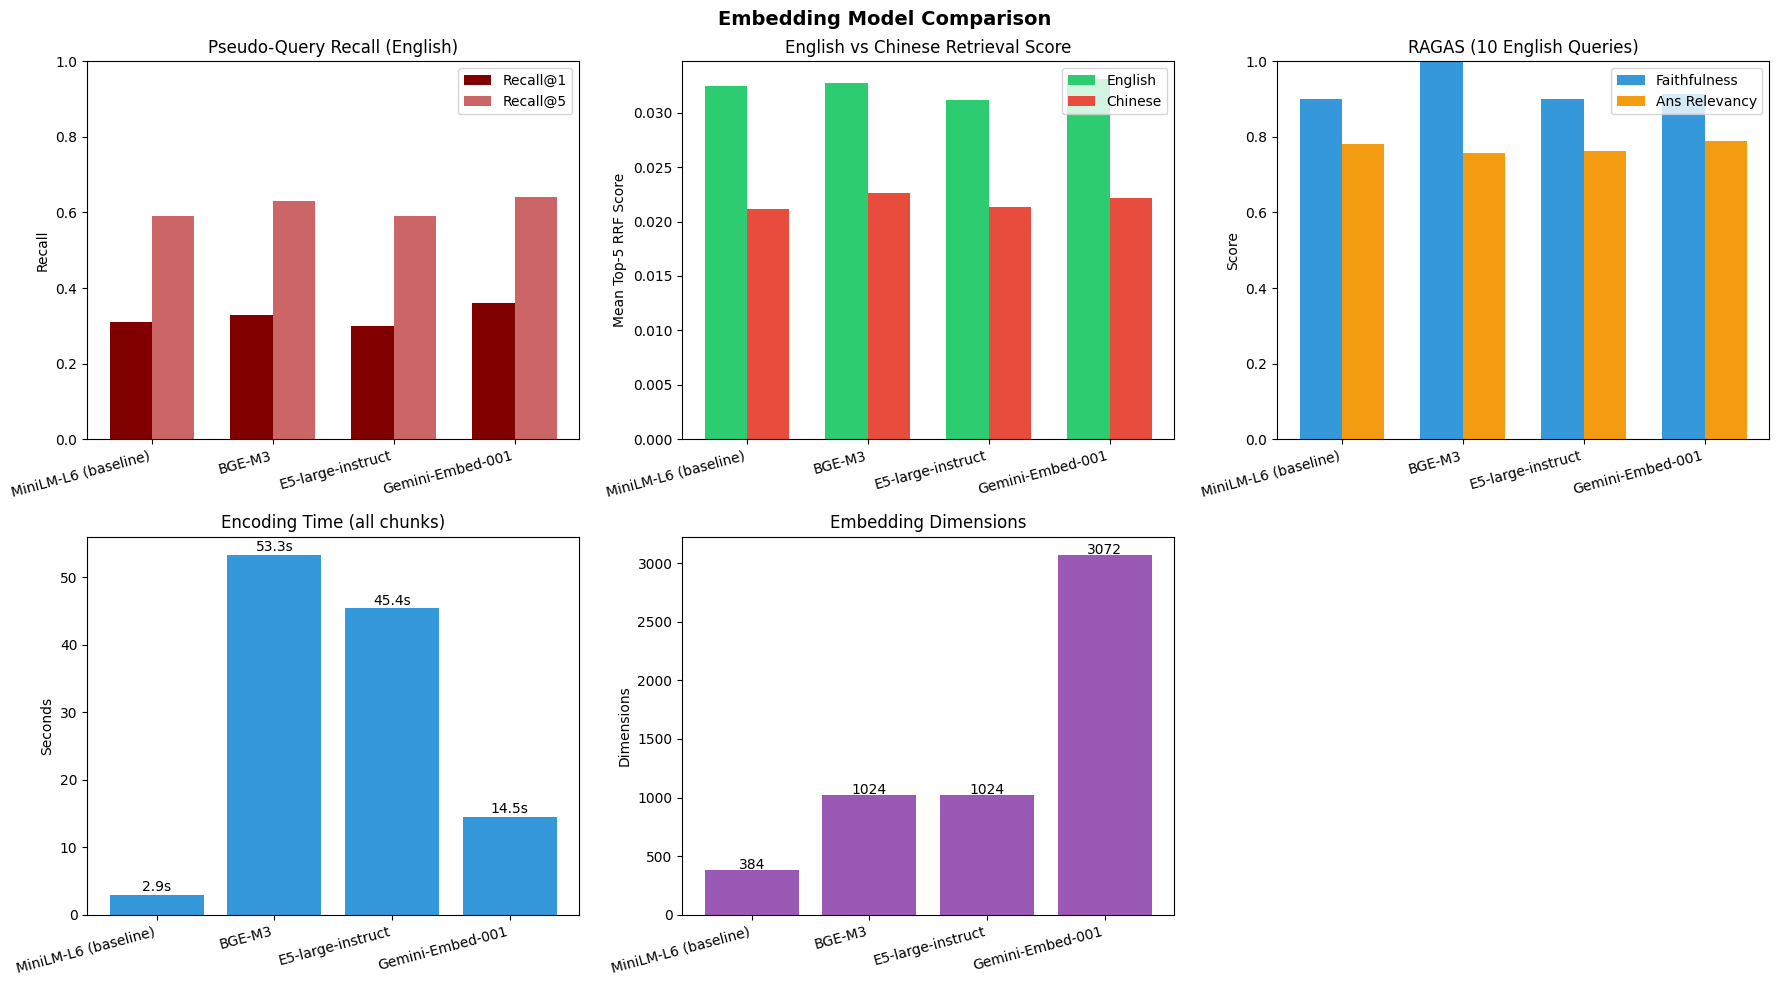

In [14]:
labels = list(models.keys())
r1_vals = [recall_results[l]["recall@1"] for l in labels]
r5_vals = [recall_results[l]["recall@k"] for l in labels]
times = [models[l]["encode_time"] for l in labels]
dims = [models[l]["dim"] for l in labels]
en_top5 = [score_results_en[l]["topk_mean"] for l in labels]
zh_top5 = [score_results_zh[l]["topk_mean"] for l in labels]
faith_vals = [ragas_results[l]["faithfulness"] for l in labels]
relev_vals = [ragas_results[l]["answer_relevancy"] for l in labels]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

x = np.arange(len(labels))
w = 0.35

# (0,0) Recall comparison
axes[0, 0].bar(x - w/2, r1_vals, w, label="Recall@1", color="#800000")
axes[0, 0].bar(x + w/2, r5_vals, w, label="Recall@5", color="#cc6666")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(labels, rotation=15, ha="right")
axes[0, 0].set_ylabel("Recall")
axes[0, 0].set_title("Pseudo-Query Recall (English)")
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 1)

# (0,1) English vs Chinese Top-5 RRF score
axes[0, 1].bar(x - w/2, en_top5, w, label="English", color="#2ecc71")
axes[0, 1].bar(x + w/2, zh_top5, w, label="Chinese", color="#e74c3c")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(labels, rotation=15, ha="right")
axes[0, 1].set_ylabel("Mean Top-5 RRF Score")
axes[0, 1].set_title("English vs Chinese Retrieval Score")
axes[0, 1].legend()

# (0,2) RAGAS: Faithfulness & Answer Relevancy
axes[0, 2].bar(x - w/2, faith_vals, w, label="Faithfulness", color="#3498db")
axes[0, 2].bar(x + w/2, relev_vals, w, label="Ans Relevancy", color="#f39c12")
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(labels, rotation=15, ha="right")
axes[0, 2].set_ylabel("Score")
axes[0, 2].set_title("RAGAS (10 English Queries)")
axes[0, 2].legend()
axes[0, 2].set_ylim(0, 1)

# (1,0) Encode time
axes[1, 0].bar(labels, times, color="#3498db")
axes[1, 0].set_ylabel("Seconds")
axes[1, 0].set_title("Encoding Time (all chunks)")
axes[1, 0].set_xticklabels(labels, rotation=15, ha="right")
for i, t in enumerate(times):
    axes[1, 0].text(i, t + 0.5, f"{t:.1f}s", ha="center")

# (1,1) Dimensions
axes[1, 1].bar(labels, dims, color="#9b59b6")
axes[1, 1].set_ylabel("Dimensions")
axes[1, 1].set_title("Embedding Dimensions")
axes[1, 1].set_xticklabels(labels, rotation=15, ha="right")
for i, d in enumerate(dims):
    axes[1, 1].text(i, d + 10, str(d), ha="center")

# (1,2) hide unused subplot
axes[1, 2].axis("off")

fig.suptitle("Embedding Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Conclusion

### Key Findings

| Metric | MiniLM-L6 (baseline) | BGE-M3 | E5-large-instruct | Gemini-Embed-001 |
|--------|---------------------|--------|-------------------|-----------------|
| **Recall@1** | 0.310 | 0.330 | 0.300 | **0.360** |
| **Recall@5** | 0.590 | 0.630 | 0.590 | **0.640** |
| **EN Top-5 RRF** | 0.0324 | 0.0327 | 0.0312 | **0.0331** |
| **ZH Top-5 RRF** | 0.0212 | **0.0226** | 0.0213 | 0.0221 |
| **Faithfulness** | 0.900 | **1.000** | 0.900 | 0.914 |
| **Answer Relevancy** | 0.783 | 0.759 | 0.764 | **0.790** |
| **Encode Time** | **2.9s** | 53.3s | 45.4s | 14.5s |
| **Dimensions** | 384 | 1024 | 1024 | 3072 |

### Analysis

1. **English retrieval**: Gemini-Embed-001 achieves the best Recall@1 (0.360) and Recall@5 (0.640),
   followed closely by BGE-M3. E5-large-instruct performs at baseline level, offering no improvement.

2. **Chinese cross-lingual retrieval**: All models return results for all 25 Chinese queries, but
   RRF scores drop ~35-40% compared to English — expected since the corpus is entirely in English.
   BGE-M3 and Gemini-Embed-001 lead in cross-lingual score.

3. **Chinese answer quality** (most significant difference):
   - **MiniLM-L6**: Retrieves irrelevant context for Chinese queries; sometimes returns English
     responses or off-topic answers (e.g., describes Data Science Clinic when asked about core courses).
   - **BGE-M3 / E5-large-instruct**: Retrieve partially relevant context but answers lack detail
     (e.g., "6 core courses" without listing them).
   - **Gemini-Embed-001**: Consistently retrieves the correct context and produces detailed, accurate
     Chinese answers (e.g., lists all core course names in Chinese).

4. **RAGAS evaluation**: BGE-M3 achieves perfect Faithfulness (1.0), meaning its answers never
   hallucinate beyond the retrieved context. Gemini-Embed-001 leads in Answer Relevancy (0.790),
   indicating its answers are most on-topic.

5. **Performance**: MiniLM-L6 is fastest (2.9s) as expected for a small local model.
   Gemini-Embed-001 (14.5s via API) is significantly faster than the two large local models
   (BGE-M3: 53.3s, E5: 45.4s), despite producing 3072-dim embeddings.

### Recommendation

- **For production with Chinese support**: Switch to **Gemini-Embed-001**. It ranks first in English
  retrieval quality, Answer Relevancy, and Chinese answer quality, while being faster than
  local alternatives. The free API tier (10M tokens/min) is more than sufficient for this project.
- **For offline/API-free deployment**: **BGE-M3** is the strongest local alternative, with perfect
  Faithfulness and the best cross-lingual scores among open-source models.
- **E5-large-instruct** does not justify its cost (45s encode time, 2.2GB model) over the baseline
  — it can be excluded from further consideration.